# Characterizing parameter uncertainty with MLE asymptotics

## Exposition

## MLE Asymptotics
Recall that an MLE estimator converges in distribution to a normal distribution:

$$ \sqrt{n}(\hat{\theta}_{mle} - \theta) \to N(0, I^{-1}(\theta))$$

where $I(\theta)$ is the Fisher information matrix. Assuming the asymptotic approximation holds for $n = 6$, we can thus characterize parameter uncertainty by sampling from the distribution 

$$N(\hat{\theta}_{mle}, \hat{V})$$

where $\hat{V} = I^{-1}(\hat{\theta}_{mle})$.

## Reparametrization

Our ultimate parameter of interest is $\theta = (p_0, \xi, \sigma)$ with parameter bounds:

$$ 0 \leq p_0 \leq 1$$
$$ \xi > -1$$
$$ \sigma > 0$$

To obtain estimated parameter distributions respecting these boundaries, we conduct MLE using the following reparametrizations:

$$p_0 = \frac{1}{1 + e^{\phi_1}}$$
$$\xi = -1 + \ln(1 + e^{\phi_2})$$
$$\sigma = \ln({1 + e^{\phi_3}})$$

This gives us $\hat{\phi} = (\hat{\phi_1}, \hat{\phi_2}, \hat{\phi_3})$, which live in unconstrained real number domains. Assuming MLE asymptotics have kicked in these are approximately distributed $N(\hat{\phi}, \hat{V_{\phi}})$.

To obtain parameter distributions over $\theta$, we simply sample from $N(\hat{\phi}, \hat{V_{\phi}})$ and transform back to the constrained space using the inverses of the reparametrization functions.

### Execution and results

In [206]:
import matplotlib.pyplot as plt
import numdifftools as nd
import numpy as np
import pandas as pd
from scipy.optimize import approx_fprime, minimize
from scipy.stats import genpareto

from pandemic_model.stats.mevd import MEVD, TruncatedGPD
from pandemic_model.stats.utils import taleb_transform, taleb_inverse

In [174]:
rng = np.random.default_rng()
THRESHOLD = 0.01
MAX_INTENSITY = 100

In [175]:
# Load actual duration data
final_allrisk_ds = pd.read_csv("../../data/clean/final_allrisk_ds.csv")

intensity_data = final_allrisk_ds['intensity']
duration_data = final_allrisk_ds['duration']

intensity_annual = final_allrisk_ds.set_index('year_start')['intensity'].copy()

# Fill in zeros for years with no observations.
all_years = pd.Series(range(1900, 2023 + 1))
intensity_annual = intensity_annual.reindex(all_years, fill_value=0)

In [176]:
severity_annual = final_allrisk_ds.set_index('year_start')['severity'].copy()
severity_annual = severity_annual.reindex(all_years, fill_value=0)

In [177]:
exceed_idx = intensity_annual > THRESHOLD
n_exceed = exceed_idx.sum()
n_years = len(intensity_annual)
excesses = intensity_annual[exceed_idx]

In [196]:
def logit(p):            # (0,1) -> ℝ
    return np.log(p) - np.log1p(-p)

def sigmoid(psi):        # ℝ -> (0,1)
    return 1.0 / (1.0 + np.exp(-psi))

def softplus_inv(z):     # (0,∞) -> ℝ   – inverse of log1p(exp(·))
    return np.log(np.expm1(z))

def softplus(phi):       # ℝ -> (0,∞)
    return np.log1p(np.exp(phi))

def softplus1_inv(xi):   # (-1,∞) -> ℝ   – inverse of log1p(exp(·))-1
    return np.log(np.expm1(xi + 1.0))

def softplus1(phi):      # ℝ -> (-1,∞)
    return np.log1p(np.exp(phi)) - 1.0

def to_phi(theta):
    """θ = (p, ξ, σ)  →  φ = (ψ, φ₁, φ₂)  all in ℝ"""
    p, xi, sigma = theta
    return np.array([logit(p), softplus1_inv(xi), softplus_inv(sigma)])

def from_phi(phi):
    """φ = (ψ, φ₁, φ₂) → θ = (p, ξ, σ)  all valid"""
    psi, phi1, phi2 = phi
    return np.array([sigmoid(psi), softplus1(phi1), softplus(phi2)])

# ------------------------------------------------------------------
# 2.  NEGATIVE LOG-LIKELIHOOD  (optionally truncated)
# ------------------------------------------------------------------
def nll_phi(phi, y, n_years, n_exceed, y_max=None):
    """Negative log-likelihood of exceedances y (>0) given φ=(ψ,φ1,φ2)."""
    p, xi, sigma = from_phi(phi)

    # Binomial term for p
    ll = n_exceed * np.log(p) + (n_years - n_exceed) * np.log1p(-p)
    
    # GPD term for (xi,sigma)
    ll += genpareto.logpdf(y, c=xi, scale=sigma).sum()

    # add truncation term if an upper limit exists
    if y_max is not None and np.isfinite(y_max):
        ll -= n_exceed * genpareto.logcdf(y_max, c=xi, scale=sigma)

    return -ll

def grad(f, x, eps=1e-7):
    """Numerical gradient approximation."""
    return approx_fprime(x, f, eps)

def hess(f, x, eps=1e-4):
    """Numerical Hessian approximation."""
    n = len(x)
    H = np.empty((n, n), float)
    ei = np.zeros(n)

    # central differences for second partials
    for i in range(n):
        ei[i] = eps
        for j in range(i, n):
            ej = np.zeros_like(ei)
            ej[j] = eps
            
            H[i, j] = (
                f(x + ei + ej) - f(x + ei - ej)
              - f(x - ei + ej) + f(x - ei - ej)
            ) / (4 * eps * eps)
            H[j, i] = H[i, j]
        ei[i] = 0.0

    # tiny asymmetry/round-off
    return H

# ------------------------------------------------------------------
# 3.  MULTI-START MLE FOR (p,ξ,σ)
# ------------------------------------------------------------------
def fit_tail(excesses, n_years, n_exceed, start_grid, y_max=None):
    results = []
    for p0, xi0, sig0 in start_grid:
        phi0 = to_phi((p0, xi0, sig0))
        
        # Nelder-Mead optimization
        nelder_mead_opts = {
            'maxiter': 10000,
            'maxfev': 50000,
            'xatol': 1e-4,
            'fatol': 1e-4,
            'adaptive': True
        }
        
        opt = minimize(nll_phi, phi0, args=(excesses, n_years, n_exceed, y_max),
                      method='Nelder-Mead', options=nelder_mead_opts)
        
        if not opt.success:
            error_msg = f"Optimization failed: {opt.message}\n"
            error_msg += f"Status: {opt.status}\n"
            error_msg += f"Number of iterations: {opt.nit}\n"
            error_msg += f"Final function value: {opt.fun}\n"
            error_msg += f"Final parameters: {from_phi(opt.x)}"
            raise RuntimeError(error_msg)
            
        # Calculate full Hessian at optimal point
        info = hess(lambda x: nll_phi(x, excesses, n_years, n_exceed, y_max), opt.x)
        cov = np.linalg.inv(info)  # asymptotic covariance
        
        est_p, est_xi, est_sigma = from_phi(opt.x)
        results.append({
            "start":   (p0, xi0, sig0),
            "p":       est_p,
            "xi":      est_xi,
            "sigma":   est_sigma,
            "opt":     opt,
            "success": opt.success,
            "fun":     opt.fun,
            "hess_inv": cov
        })
    df = pd.DataFrame(results)
    best = df.loc[df.fun.idxmin()]
    return df, best

p_mle = n_exceed / n_years
start_grid = [
    (p_mle * 0.25, 0.1,  excesses.mean()),
    (p_mle * 0.5, 0.5,  excesses.mean()),
    (p_mle * 0.75, -0.1, excesses.std()),
    (p_mle * 1.25, 0.2,  np.median(excesses)),
    (p_mle * 1.5, 3.0,  excesses.mean()),
    (p_mle * 0.1, 0.1, excesses.mean()),
    (p_mle * 2.0, 0.1, excesses.mean()),
]

results_df, best_fit = fit_tail(excesses, n_years, n_exceed, start_grid, y_max=None)
print("MLE estimates from different initial conditions")
display(results_df)

p_hat, xi_hat, sigma_hat = best_fit.p, best_fit.xi, best_fit.sigma

# ------------------------------------------------------------------
# 4.  VARIANCE–COVARIANCE IN φ-SPACE
# ------------------------------------------------------------------
# Get full covariance matrix from Hessian
V_phi = best_fit.hess_inv

# point-estimate in φ-space
phi_hat = np.array([logit(p_hat), softplus1_inv(xi_hat), softplus_inv(sigma_hat)])
theta_hat = from_phi(phi_hat)
V_phi

MLE estimates from different initial conditions


,start,p,xi,sigma,opt,success,fun,hess_inv
0,"(0.012096774193548387, 0.1, 11.01733931590906)",0.048387,1.005628,2.311361,"{'fun': 41.08431523088377, 'nit': 106, 'nfev':...",True,41.084315,"[[0.17514198057061414, -2.043859037581538e-08,..."
1,"(0.024193548387096774, 0.5, 11.01733931590906)",0.048387,1.005589,2.311353,"{'fun': 41.084315231607405, 'nit': 107, 'nfev'...",True,41.084315,"[[0.17514125586676246, -2.043648984311757e-08,..."
2,"(0.03629032258064516, -0.1, 22.519641875747737)",0.048387,1.005599,2.311378,"{'fun': 41.08431523121874, 'nit': 102, 'nfev':...",True,41.084315,"[[0.17514311940306915, 0.0, 0.0], [0.0, 0.6569..."
3,"(0.06048387096774194, 0.2, 1.9307200922430425)",0.048386,1.005595,2.311387,"{'fun': 41.08431523144097, 'nit': 92, 'nfev': ...",True,41.084315,"[[0.1751433591591575, 0.0, 0.0], [0.0, 0.65689..."
4,"(0.07258064516129031, 3.0, 11.01733931590906)",0.048387,1.005598,2.311374,"{'fun': 41.08431523095233, 'nit': 95, 'nfev': ...",True,41.084315,"[[0.17514206230450696, 0.0, 0.0], [0.0, 0.6569..."
5,"(0.004838709677419355, 0.1, 11.01733931590906)",0.048388,1.005647,2.311368,"{'fun': 41.08431523219521, 'nit': 118, 'nfev':...",True,41.084315,"[[0.17513946320405635, 6.062932417344348e-09, ..."
6,"(0.0967741935483871, 0.1, 11.01733931590906)",0.048387,1.005625,2.311322,"{'fun': 41.08431523124523, 'nit': 103, 'nfev':...",True,41.084315,"[[0.17514159914678898, 6.062207958813735e-09, ..."


array([[ 1.75141981e-01, -2.04385904e-08,  1.43762841e-08],
       [-2.04385904e-08,  6.56947207e-01, -4.62089583e-01],
       [ 1.43762841e-08, -4.62089583e-01,  3.22642891e+00]])

In [202]:
results_df, best_fit = fit_tail(excesses, n_years, n_exceed, start_grid, y_max=57-THRESHOLD)
print("MLE estimates from different initial conditions")
display(results_df)

p_hat, xi_hat, sigma_hat = best_fit.p, best_fit.xi, best_fit.sigma

# ------------------------------------------------------------------
# 4.  VARIANCE–COVARIANCE IN φ-SPACE
# ------------------------------------------------------------------
# Get full covariance matrix from Hessian
V_phi = best_fit.hess_inv

# point-estimate in φ-space
phi_hat = np.array([logit(p_hat), softplus1_inv(xi_hat), softplus_inv(sigma_hat)])
theta_hat = from_phi(phi_hat)
V_phi

MLE estimates from different initial conditions


,start,p,xi,sigma,opt,success,fun,hess_inv
0,"(0.012096774193548387, 0.1, 11.01733931590906)",0.048387,1.864196,2.587475,"{'fun': 40.686428510715224, 'nit': 113, 'nfev'...",True,40.686429,"[[0.1751401279561621, 4.023848273203268e-08, 1..."
1,"(0.024193548387096774, 0.5, 11.01733931590906)",0.048387,1.864260,2.587498,"{'fun': 40.686428510581386, 'nit': 110, 'nfev'...",True,40.686429,"[[0.17514097252554026, -2.2251652817348173e-07..."
2,"(0.03629032258064516, -0.1, 22.519641875747737)",0.048387,1.864231,2.587514,"{'fun': 40.68642851070153, 'nit': 131, 'nfev':...",True,40.686429,"[[0.17514233475136942, 0.0, 0.0], [0.0, 7.1518..."
3,"(0.06048387096774194, 0.2, 1.9307200922430425)",0.048387,1.864261,2.587448,"{'fun': 40.68642851086347, 'nit': 84, 'nfev': ...",True,40.686429,"[[0.17514041674347874, 0.0, 0.0], [0.0, 7.1521..."
4,"(0.07258064516129031, 3.0, 11.01733931590906)",0.048387,1.864266,2.587463,"{'fun': 40.68642851070595, 'nit': 103, 'nfev':...",True,40.686429,"[[0.1751412340712556, 4.0247035274445436e-08, ..."
5,"(0.004838709677419355, 0.1, 11.01733931590906)",0.048387,1.864215,2.587522,"{'fun': 40.68642851067542, 'nit': 119, 'nfev':...",True,40.686429,"[[0.17514163184019882, 2.2249541850632479e-07,..."
6,"(0.0967741935483871, 0.1, 11.01733931590906)",0.048387,1.864270,2.587514,"{'fun': 40.686428510692274, 'nit': 115, 'nfev'...",True,40.686429,"[[0.1751416318401919, 0.0, 0.0], [0.0, 7.15246..."


array([[ 1.75140973e-01, -2.22516528e-07, -4.02495503e-08],
       [-2.22516528e-07,  7.15227667e+00,  1.29372825e+00],
       [-4.02495503e-08,  1.29372825e+00,  5.56606505e+00]])

In [203]:
V_phi

array([[ 1.75140973e-01, -2.22516528e-07, -4.02495503e-08],
       [-2.22516528e-07,  7.15227667e+00,  1.29372825e+00],
       [-4.02495503e-08,  1.29372825e+00,  5.56606505e+00]])

In [204]:
# ------------------------------------------------------------------
# 5.  MONTE-CARLO DRAWS  →  θ-SPACE
# ------------------------------------------------------------------
n_samples  = 100_000
phi_draws  = rng.multivariate_normal(phi_hat, V_phi, size=n_samples)
theta_draws = np.vstack([from_phi(phi_row) for phi_row in phi_draws])
p_draws, xi_draws, sigma_draws = np.hsplit(theta_draws, 3) # convenient unpack

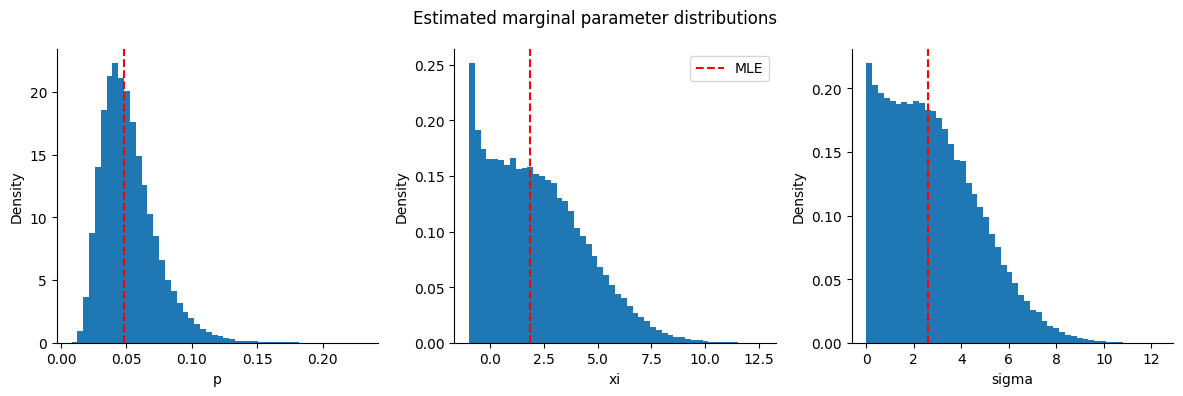

In [205]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
param_names = ['p', 'xi', 'sigma']

for i, (ax, name) in enumerate(zip(axes, param_names)):
    ax.hist(theta_draws[:, i], bins=50, density=True)
    ax.axvline(theta_hat[i], color='red', linestyle='--', label='MLE')
    ax.set_xlabel(name)
    ax.set_ylabel('Density')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 1:
    	ax.legend()

plt.suptitle("Estimated marginal parameter distributions")
plt.tight_layout()
plt.show()

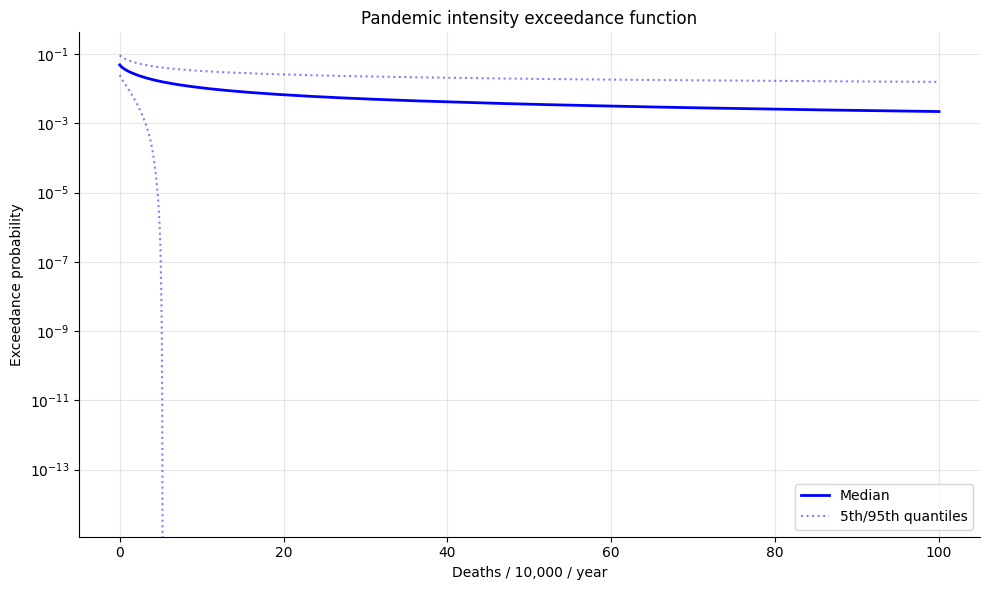

<Figure size 640x480 with 0 Axes>

In [195]:
# Create intensity thresholds
intensity_thresholds = np.logspace(np.log10(THRESHOLD), np.log10(MAX_INTENSITY), 1000)
intensity_thresholds_mat = np.tile(intensity_thresholds, (n_samples, 1))

# Calculate survival functions for each sample
intensity_survivals = (
    p_draws * (1 - genpareto.cdf(
        intensity_thresholds_mat,
        xi_draws,
        loc=THRESHOLD,
        scale=sigma_draws
    ) 
    # / genpareto.cdf(MAX_INTENSITY, c=xi_draws, loc=THRESHOLD, scale=sigma_draws)
    )
)

# Calculate percentiles for credible intervals
intensity_percentiles = np.percentile(intensity_survivals, [5, 50, 95], axis=0)

# Plot exceedance probability curve
plt.figure(figsize=(10, 6))

# Plot median and credible intervals
plt.plot(intensity_thresholds, intensity_percentiles[1], 'b-', linewidth=2, label='Median')
plt.plot(intensity_thresholds, intensity_percentiles[0], 'b:', alpha=0.5, label='5th/95th quantiles')
plt.plot(intensity_thresholds, intensity_percentiles[2], 'b:', alpha=0.5)

plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.xlabel('Deaths / 10,000 / year')
plt.ylabel('Exceedance probability')
plt.title('Pandemic intensity exceedance function')
plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
plt.savefig("../../output/severity_distributions/allrisk_base_exceedance_fn.jpg", dpi=400)

Save the samples

In [184]:
out_sample = pd.DataFrame(
  theta_draws,
  columns=['p', 'xi', 'sigma']
)
out_sample['max_value'] = MAX_INTENSITY
out_sample.to_csv("../../output/severity_distributions/allrisk_base_mevd_samples.csv", index=False)

Also create sample based on MLE estimates

In [185]:
mle_sample = pd.DataFrame(
    np.tile(theta_hat, (n_samples, 1)),
    columns=['p', 'xi', 'sigma']
)
mle_sample['max_value'] = MAX_INTENSITY
mle_sample.to_csv("../../output/severity_distributions/allrisk_base_mevd_mle.csv", index=False)